In [1]:
import os
import bisect
import numpy as np
from scipy.stats import linregress
from scipy.interpolate import UnivariateSpline
import matplotlib as mpl
import matplotlib.pyplot as plt
from RSCpp import IOfuncs as iof
from RSCpp import RheoConfig as rconf
from RSCpp import RheoCorr as rcorr
from RSCpp import FTrheo as ft
from RSCpp import AnalysisFuncs as af
from RSCpp import SharedFunctions as sf
from pathlib import Path
import warnings

mpl.rcParams['figure.figsize'] = (20, 10)

import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger = logging.getLogger('matplotlib')
logger.setLevel(logging.WARNING)
logging.info('ShearCell postproc tutorial started')

INFO:root:ShearCell postproc tutorial started


# Shear cell rheology post processing

This tutorial explains how to load and analyze rheology experiments done with the shear cell

### 1. Locate data and reconstruct rheology protocol

Data should be in the output folder of the rheology program. Three types of files should be in there:

- ```Config_Rheo.ini```: the configuration file used by the rheology program
- ```expLog.txt```: the log file with the list of the intervals that have been generated by the rheology program
- A list of file with name structure ```PREFIX[a][_POS/NEG].txt```, with:
  - ```PREFIX``` a prefix specified in the ```Name``` field of ```expLog.txt```
  - ```[a]``` a character suffix that counts how many times that interval has been repeated
  - ```[_POS/NEG]``` eventually, another suffix to distinguish positive and negative ramps

Information on rheology protocol is lodaded in ```RheoConfig.RheoProtocol``` object using the function

```python
rconf.RheoProtocol(config_folder, config_fname='Config_Rheo.ini', explog_fname='expLog.txt')
```

In [2]:
froot = r'D:\Suri\260617_100um_30perc\04_Direction_4'
rheo_protocol = rconf.RheoProtocol(froot)
print(rheo_protocol)

INFO:root:27 rows read from expLog file D:\Suri\260617_100um_30perc\04_Direction_4\expLog.txt
INFO:root:expLog file updated with 27 output file paths


<RheoProtocol (26 intervals)>


This object can be used to reconstruct a dataset with each interval's setting, including the output file path, using 

```python
RheoProtocol.LoadExpLog(force_reload=False, load_fnames=True)
```

**NOTE**: this file path is reconstructed based on the assumption that the file naming hasn't changed. This assumption can be wrong for old data. 

The program checks if the reconstructed file path corresponds to a file that really exists.

In [3]:
rheo_explog = rheo_protocol.LoadExpLog()
rheo_explog

,ID,Time,Type,Name,Force,Displacement,Speed,Period,Offset,RelOffset,...,StartPos,EndPos,StartForce,EndForce,Trigger,Active,Axis,StrainControlled,FilePath,FilePath_exists
0,2,7.17139,4,01_Ramp_Rate,<err>,7,1,<err>,0,1,...,11,18,0.00251778,0.00327311,0,1,1,1,D:\Suri\260617_100um_30perc\04_Direction_4\01_...,True
1,2,14.3172,4,01_Ramp_Rate,<err>,7,1,<err>,0,1,...,18,11,0.0031724,0.00320597,0,1,1,1,D:\Suri\260617_100um_30perc\04_Direction_4\01_...,True
2,3,20.9882,2,02_Preshear_+,<err>,5,1,6,0,1,...,11,16,0.00364238,0.00706656,0,1,1,1,D:\Suri\260617_100um_30perc\04_Direction_4\02_...,True
3,4,24.6618,2,03_Readout_++,<err>,2,1,3,0,1,...,16,18,0.00785546,0.00375988,0,1,1,1,D:\Suri\260617_100um_30perc\04_Direction_4\03_...,True
4,5,31.3274,2,04_Preshear_-,<err>,-5,-1,6,0,1,...,18,13,0.00290384,0.00617695,0,1,1,1,D:\Suri\260617_100um_30perc\04_Direction_4\04_...,True
5,6,34.9999,2,05_Readout_--,<err>,-2,-1,3,0,1,...,13,11,0.00617695,0.00471664,0,1,1,1,D:\Suri\260617_100um_30perc\04_Direction_4\05_...,True
6,7,42.6814,2,06_Preshear_+_6,<err>,6,1,7,0,1,...,11,17,0.00236671,0.00558947,0,1,1,1,D:\Suri\260617_100um_30perc\04_Direction_4\06_...,True
7,8,50.3674,2,07_Readout_+-_6,<err>,-6,-1,7,0,1,...,17,11,0.0048677,0.00360881,0,1,1,1,D:\Suri\260617_100um_30perc\04_Direction_4\07_...,True
8,9,57.0453,2,08_Preshear_+_5,<err>,5,1,6,0,1,...,11,16,0.00421308,0.00753655,0,1,1,1,D:\Suri\260617_100um_30perc\04_Direction_4\08_...,True
9,10,63.719,2,09_Readout_+-_5,<err>,-5,-1,6,0,1,...,16,11,0.00703299,0.00334025,0,1,1,1,D:\Suri\260617_100um_30perc\04_Direction_4\09_...,True


INFO:root:Auto-detected suffix length: 0 (27 files detected)


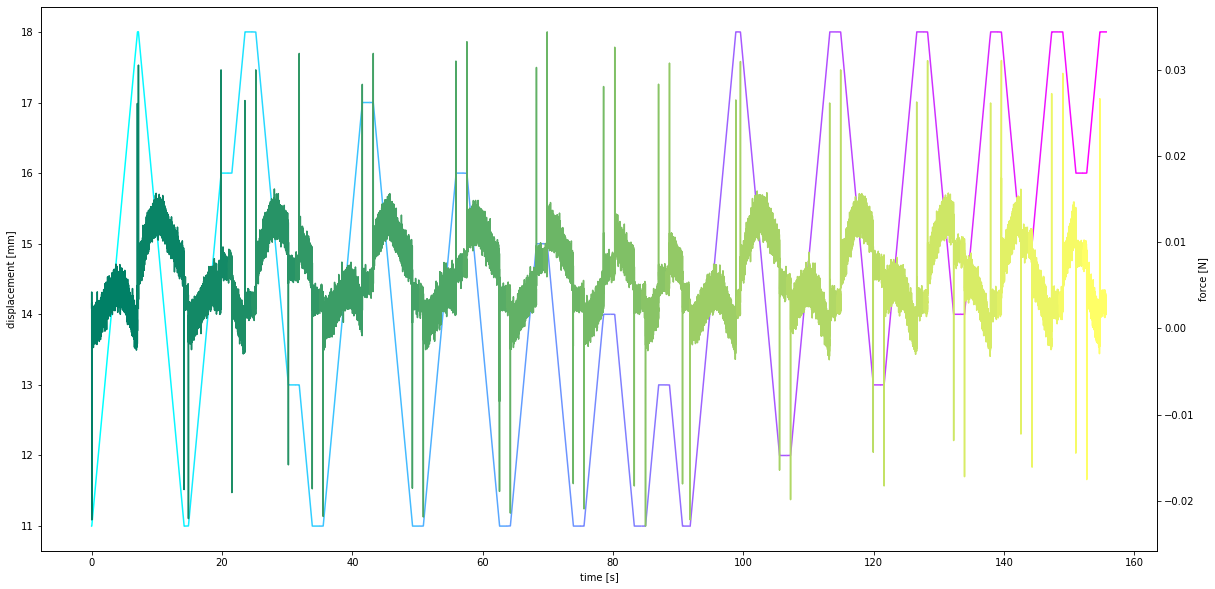

In [4]:
_ = af.BatchProcess(rheo_explog, anal_type='plot', anal_params={'plot_type':'time', 'global_time':'auto'})

INFO:root:Auto-detected suffix length: 0 (27 files detected)


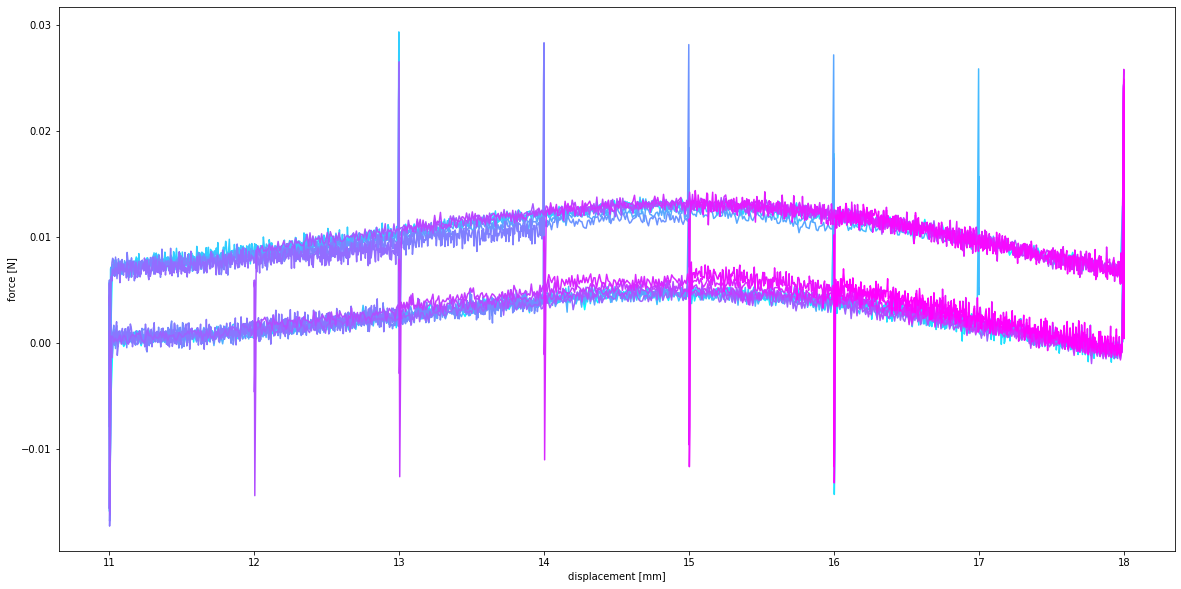

In [5]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
_ = af.BatchProcess(rheo_explog, decimate=10, anal_type='plot', anal_params={'plot_type':'stressstrain'})

INFO:root:Auto-detected suffix length: 0 (2 files detected)


Text(0, 0.5, '$F-F_0$ [N]')

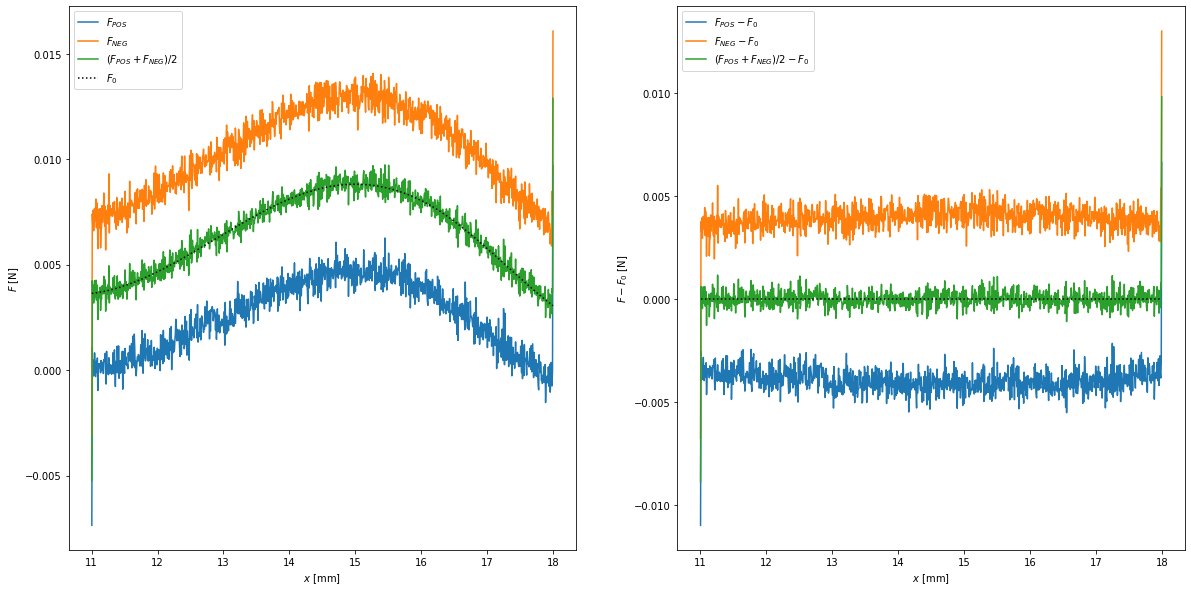

In [6]:
calib_ramp = af.BatchProcess(rheo_explog, filter_name='Ramp', max_num=2, anal_type='read')

nbins = 1000
common_x, F_POS = sf.Decimate(calib_ramp[0][2], q=nbins, x=calib_ramp[0][1], bin_spacing='lin', q_meaning='num', return_opts=False)
common_x, F_NEG = sf.Decimate(calib_ramp[1][2], q=nbins, x=calib_ramp[1][1], bin_spacing='lin', q_meaning='num', return_opts=False)
Foff = 0.5*(F_POS+F_NEG)

edge = 4
Foff_spl = UnivariateSpline(common_x[edge:-edge], Foff[edge:-edge], s=1.3e-4)

fig, ax = plt.subplots(ncols=2)
ax[0].plot(common_x, F_POS, label=r'$F_{POS}$')
ax[0].plot(common_x, F_NEG, label=r'$F_{NEG}$')
ax[0].plot(common_x, Foff, label=r'$(F_{POS}+F_{NEG})/2$')
ax[0].plot(common_x, Foff_spl(common_x), 'k:', label=r'$F_0$')
ax[0].legend()
ax[1].plot(common_x, F_POS-Foff_spl(common_x), label=r'$F_{POS}-F_0$')
ax[1].plot(common_x, F_NEG-Foff_spl(common_x), label=r'$F_{NEG}-F_0$')
ax[1].plot(common_x, Foff-Foff_spl(common_x), label=r'$(F_{POS}+F_{NEG})/2-F_0$')
ax[1].plot(common_x, np.zeros_like(common_x), 'k:')
ax[1].legend()
ax[0].set_xlabel(r'$x$ [mm]')
ax[0].set_ylabel(r'$F$ [N]')
ax[1].set_xlabel(r'$x$ [mm]')
ax[1].set_ylabel(r'$F-F_0$ [N]')

INFO:root:Auto-detected suffix length: 0 (12 files detected)


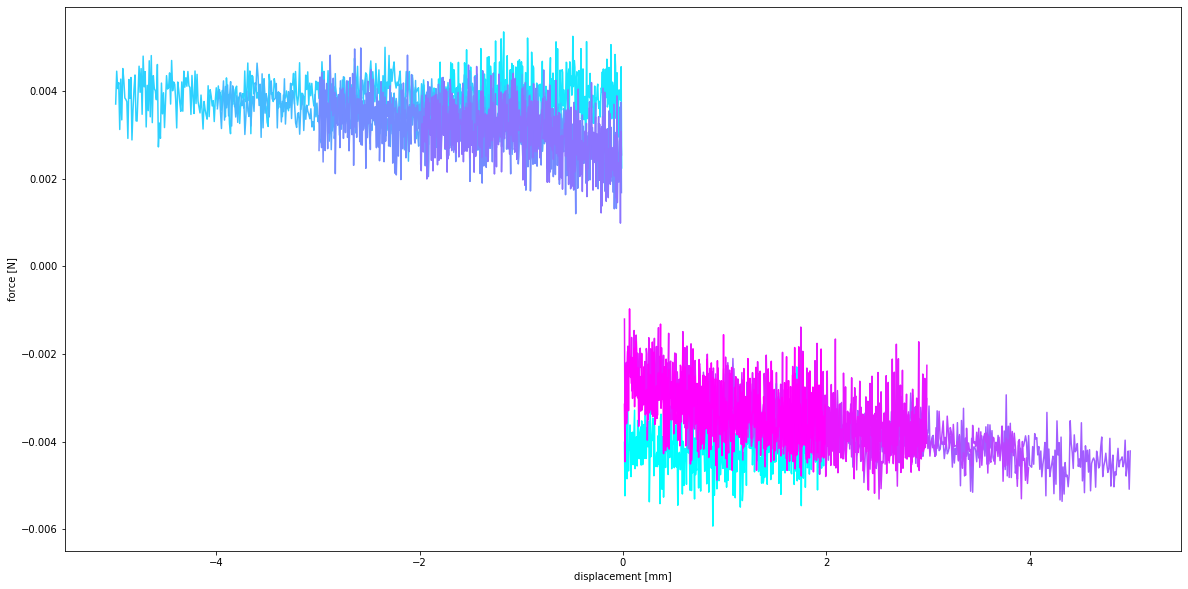

In [7]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
_ = af.BatchProcess(rheo_explog, decimate=10, anal_type='plot', filter_name='Readout', anal_params={'plot_type':'stressstrain', 'stress_corr_spl':Foff_spl, 'strain_off':'first', 'plot_slice':[105, -200]})

INFO:root:Auto-detected suffix length: 0 (5 files detected)


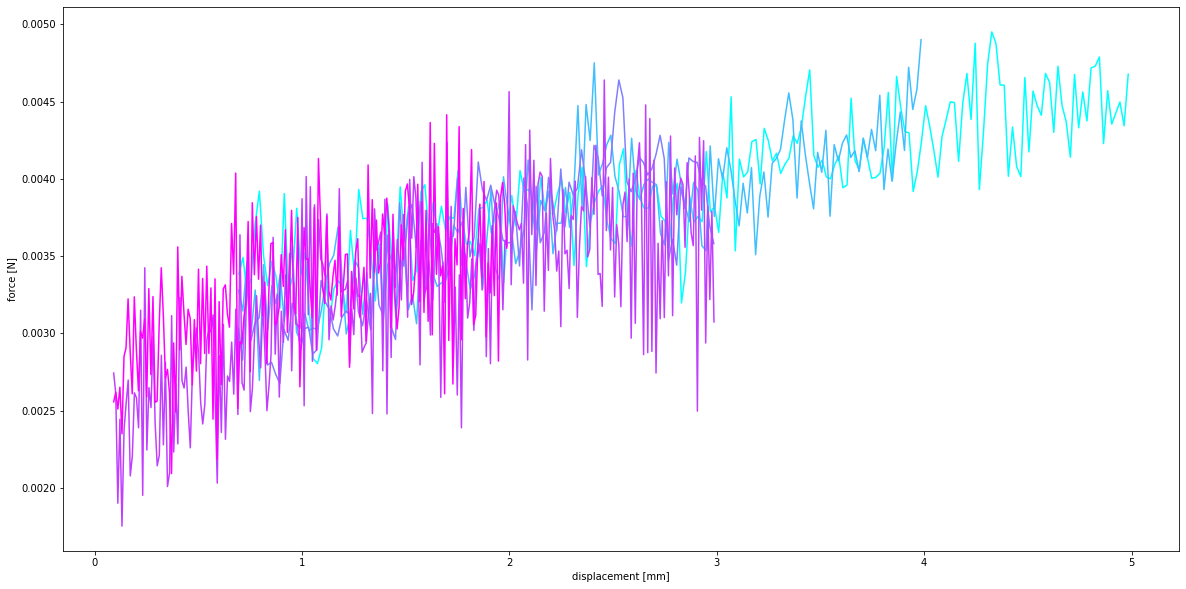

In [8]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
data = af.BatchProcess(rheo_explog, decimate=20, anal_type='plot', filter_name='Readout_-+', 
                    anal_params={'plot_type':'stressstrain', 'stress_corr_spl':Foff_spl, 'strain_off':'first', 'plot_slice':[60, -100], 'strain_abs':True, 'stress_abs':True, 'return_data':True})

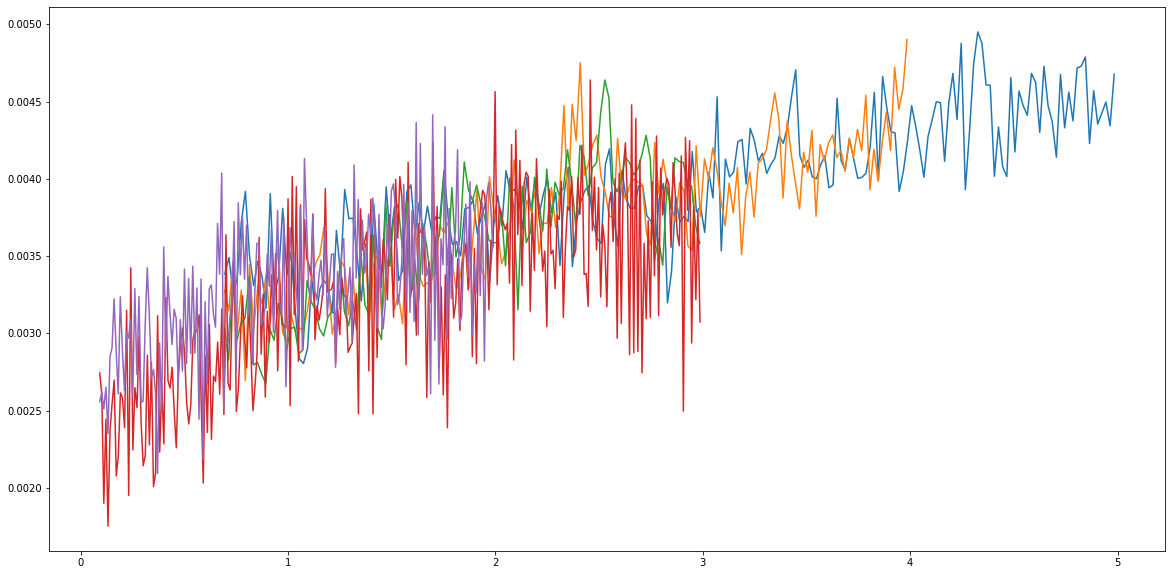

In [9]:
for x in data:
    plt.plot(x[0], x[1])

In [2]:
rheo_protocol_amp = rconf.RheoProtocol(r'D:\Suri\260617_100um_30perc\05_Amplitude_0.6')
rheo_explog_amp = rheo_protocol_amp.LoadExpLog()
rheo_explog_amp

INFO:root:40 rows read from expLog file D:\Suri\260617_100um_30perc\05_Amplitude_0.6\expLog.txt
INFO:root:expLog file updated with 40 output file paths


,ID,Time,Type,Name,Force,Displacement,Speed,Period,Offset,RelOffset,...,StartPos,EndPos,StartForce,EndForce,Trigger,Active,Axis,StrainControlled,FilePath,FilePath_exists
0,2,7.15167,4,01_Ramp_Rate,<err>,7,1,<err>,0,1,...,11,18,0.00233314,0.00231635,0,1,1,1,D:\Suri\260617_100um_30perc\05_Amplitude_0.6\0...,True
1,2,14.3149,4,01_Ramp_Rate,<err>,7,1,<err>,0,1,...,18,11,0.00292062,0.00327311,0,1,1,1,D:\Suri\260617_100um_30perc\05_Amplitude_0.6\0...,True
2,3,20.9984,2,02_Preshear_+,<err>,5,1,6,0,1,...,11,16,0.00332347,0.0072512,0,1,1,1,D:\Suri\260617_100um_30perc\05_Amplitude_0.6\0...,True
3,4,71.3321,0,03_Train_++,<err>,0.6,1.50796,2.5,0,1,...,16,16,0.00738548,0.00871151,0,1,1,1,D:\Suri\260617_100um_30perc\05_Amplitude_0.6\0...,True
4,5,74.9939,2,04_Readout_++,<err>,2,1,3,0,1,...,16,18,0.00829188,0.00308847,0,1,1,1,D:\Suri\260617_100um_30perc\05_Amplitude_0.6\0...,True
5,6,81.6589,2,05_Preshear_-,<err>,-5,-1,6,0,1,...,18,13,0.00228278,0.00773797,0,1,1,1,D:\Suri\260617_100um_30perc\05_Amplitude_0.6\0...,True
6,7,131.984,0,06_Train_--,<err>,0.6,1.50796,2.5,0,1,...,13,13,0.0072512,0.00619373,0,1,1,1,D:\Suri\260617_100um_30perc\05_Amplitude_0.6\0...,True
7,8,135.646,2,07_Readout_--,<err>,-2,-1,3,0,1,...,13,11,0.00639515,0.00258492,0,1,1,1,D:\Suri\260617_100um_30perc\05_Amplitude_0.6\0...,True
8,9,143.323,2,08_Preshear_+_6,<err>,6,1,7,0,1,...,11,17,0.00236671,0.00525376,0,1,1,1,D:\Suri\260617_100um_30perc\05_Amplitude_0.6\0...,True
9,10,194.896,0,09_Train_+-,<err>,0.6,1.50796,2.5,0,1,...,17,17,0.00574053,0.00652944,0,1,1,1,D:\Suri\260617_100um_30perc\05_Amplitude_0.6\0...,True


INFO:root:Auto-detected suffix length: 0 (40 files detected)


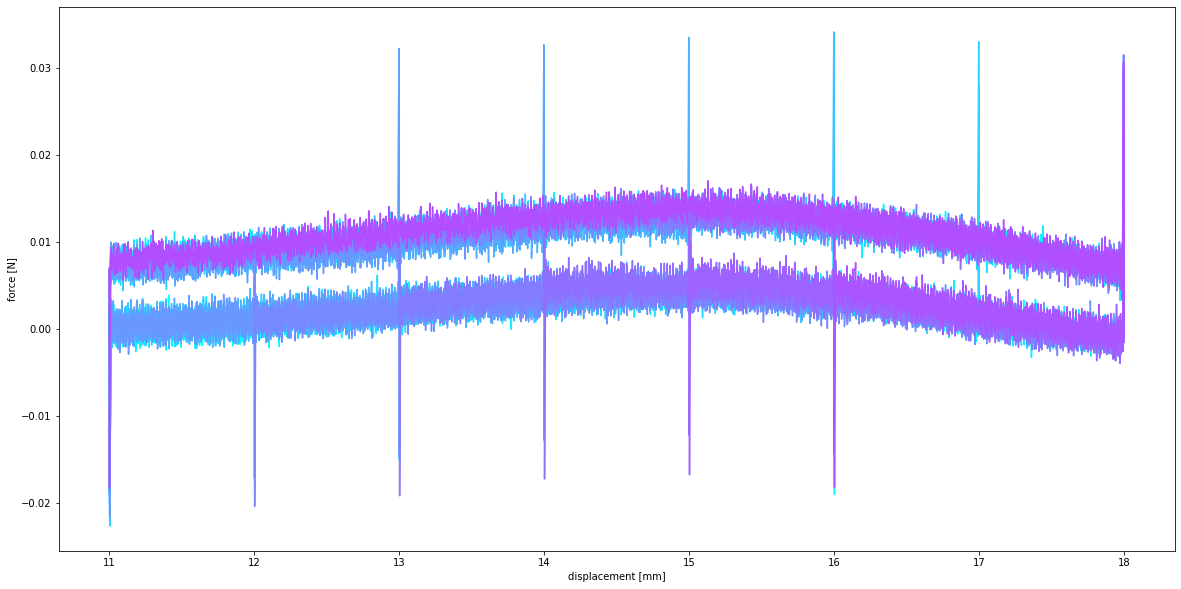

In [13]:
_ = af.BatchProcess(rheo_explog_amp, anal_type='plot', exclude_type=0, anal_params={'plot_type':'stressstrain', 'global_time':'auto'})

INFO:root:Auto-detected suffix length: 0 (5 files detected)


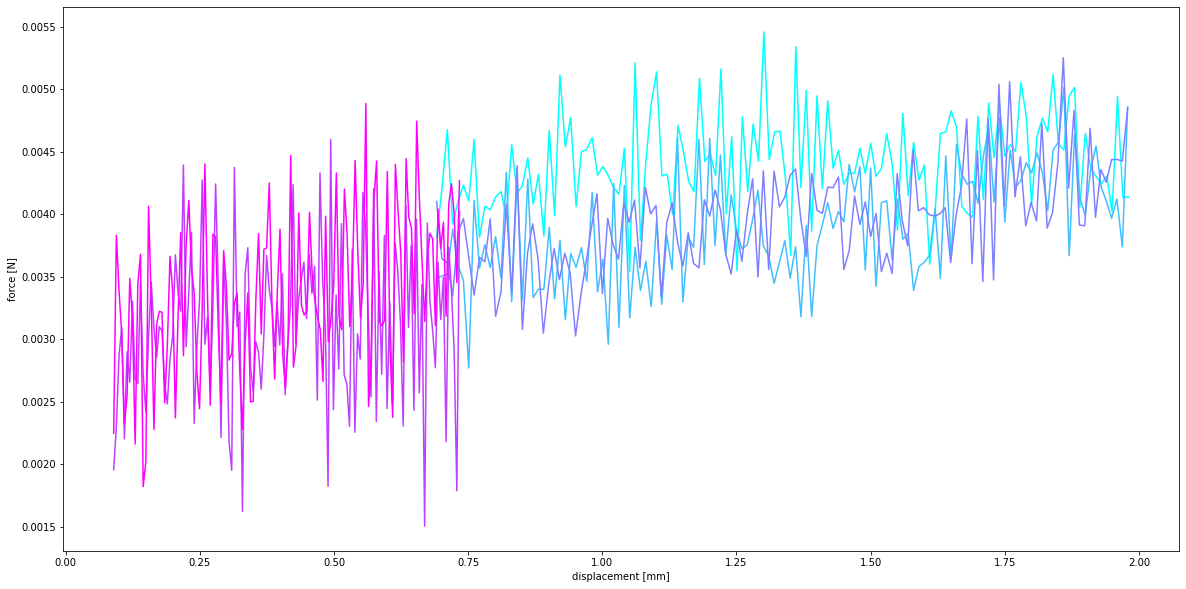

In [22]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
_ = af.BatchProcess(rheo_explog_amp, decimate=10, exclude_type=0, anal_type='plot', filter_name='Readout_-+', 
                    anal_params={'plot_type':'stressstrain', 'stress_corr_spl':Foff_spl, 'strain_off':'first', 'plot_slice':[120, 250], 'strain_abs':True, 'stress_abs':True})